In [1]:
import gc
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
import glob
import tqdm

sys.path.append("/extdata4/baeklab/Hyeonseo/m6A/modformer")
from utils.utils import printmessage

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})

In [ ]:
ON0093_df_unnorm_path = "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0093/ON0093/result/dorado-070/intermediates/segmented_tokenized/signal_analysis_unnorm/temp.merged.light.pkl"
ON0099_df_unnorm_path = "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0099/result/dorado-070/intermediates/segmented_tokenized/signal_analysis_unnorm/temp.merged.light.pkl"

In [2]:
ON0093_df_norm_path = "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0093/ON0093/result/dorado-070/intermediates/segmented_tokenized/signal_analysis/temp.merged.light.pkl"
ON0099_df_norm_path = "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0099/result/dorado-070/intermediates/segmented_tokenized/signal_analysis/temp.merged.light.pkl"

In [6]:
ON0093_df_unnorm = pd.read_pickle(ON0093_df_unnorm_path)
ON0099_df_unnorm = pd.read_pickle(ON0099_df_unnorm_path)

In [3]:
ON0093_df_norm = pd.read_pickle(ON0093_df_norm_path)
ON0099_df_norm = pd.read_pickle(ON0099_df_norm_path)

In [4]:
## Groupby 5mer and calculate mean signal
def get_motif_signal(df_dict, key = "5mer"):
    motif_dict = {}
    for k in df_dict.keys():
        df = df_dict[k]
        motif_df = df[["bq_centre", "signal_centre", "bq_avg", "signal_avg", key]].groupby(key).mean()
        motif_count_df = df[key].value_counts()
        motif_df = pd.merge(motif_df, motif_count_df, left_index = True, right_index = True)
        motif_dict[k] = motif_df
    return motif_dict

In [5]:
# df_dict = {"ON0093_unnorm": ON0093_df_unnorm, "ON0099_unnorm": ON0099_df_unnorm, "ON0093_norm": ON0093_df_norm, "ON0099_norm": ON0099_df_norm}
df_dict = {"ON0093_norm": ON0093_df_norm, "ON0099_norm": ON0099_df_norm}
for df in df_dict.values():
    # df["5mer"] = df["motif"].apply(lambda x: x[8:13])
    # df["7mer"] = df["motif"].apply(lambda x: x[7:14])
    df["9mer"] = df["motif"].apply(lambda x: x[6:15])

In [6]:
# dict_5mer = get_motif_signal(df_dict, key = "5mer")
# dict_7mer = get_motif_signal(df_dict, key = "7mer")
dict_9mer = get_motif_signal(df_dict, key = "9mer")

KeyboardInterrupt: 

In [34]:
## Plot scatter : ON0092 vs. ON0096

from scipy import stats

def plot_scatter(ax, df_dict, k1, k2, feature = "signal_avg", x_label = None, y_label = None, min_count = 100):
    merged_df = pd.merge(df_dict[k1][df_dict[k1]["count"] > min_count][[feature]],
                         df_dict[k2][df_dict[k2]["count"] > min_count][[feature]],
                         how = "inner", left_index = True, right_index = True).dropna()
    merged_df = merged_df[[f"{feature}_x", f"{feature}_y"]]
    merged_df.columns = [k1, k2]
    sns.scatterplot(x = k1, y = k2, data = merged_df, ax = ax)
    r2 = stats.pearsonr(merged_df[k1], merged_df[k2])[0]**2
    rho2 = stats.spearmanr(merged_df[k1], merged_df[k2])[0]**2
    ax.text(0.1, 0.9, f"R2: {r2:.2f}\nRho2: {rho2:.2f}", transform=ax.transAxes)
    ax.set_title(feature)
    min_val = min(np.min(merged_df[k1]), np.min(merged_df[k2]))
    max_val = max(np.max(merged_df[k1]), np.max(merged_df[k2]))
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.set_xlabel(x_label if x_label else k1)
    ax.set_ylabel(y_label if y_label else k2)
    ## trendline
    xs = np.linspace(min_val, max_val, 100)
    slope, intercept = np.polyfit(merged_df[k1], merged_df[k2], 1)
    ax.plot(xs, xs*slope + intercept, color = "red", linestyle = "--")
    
    

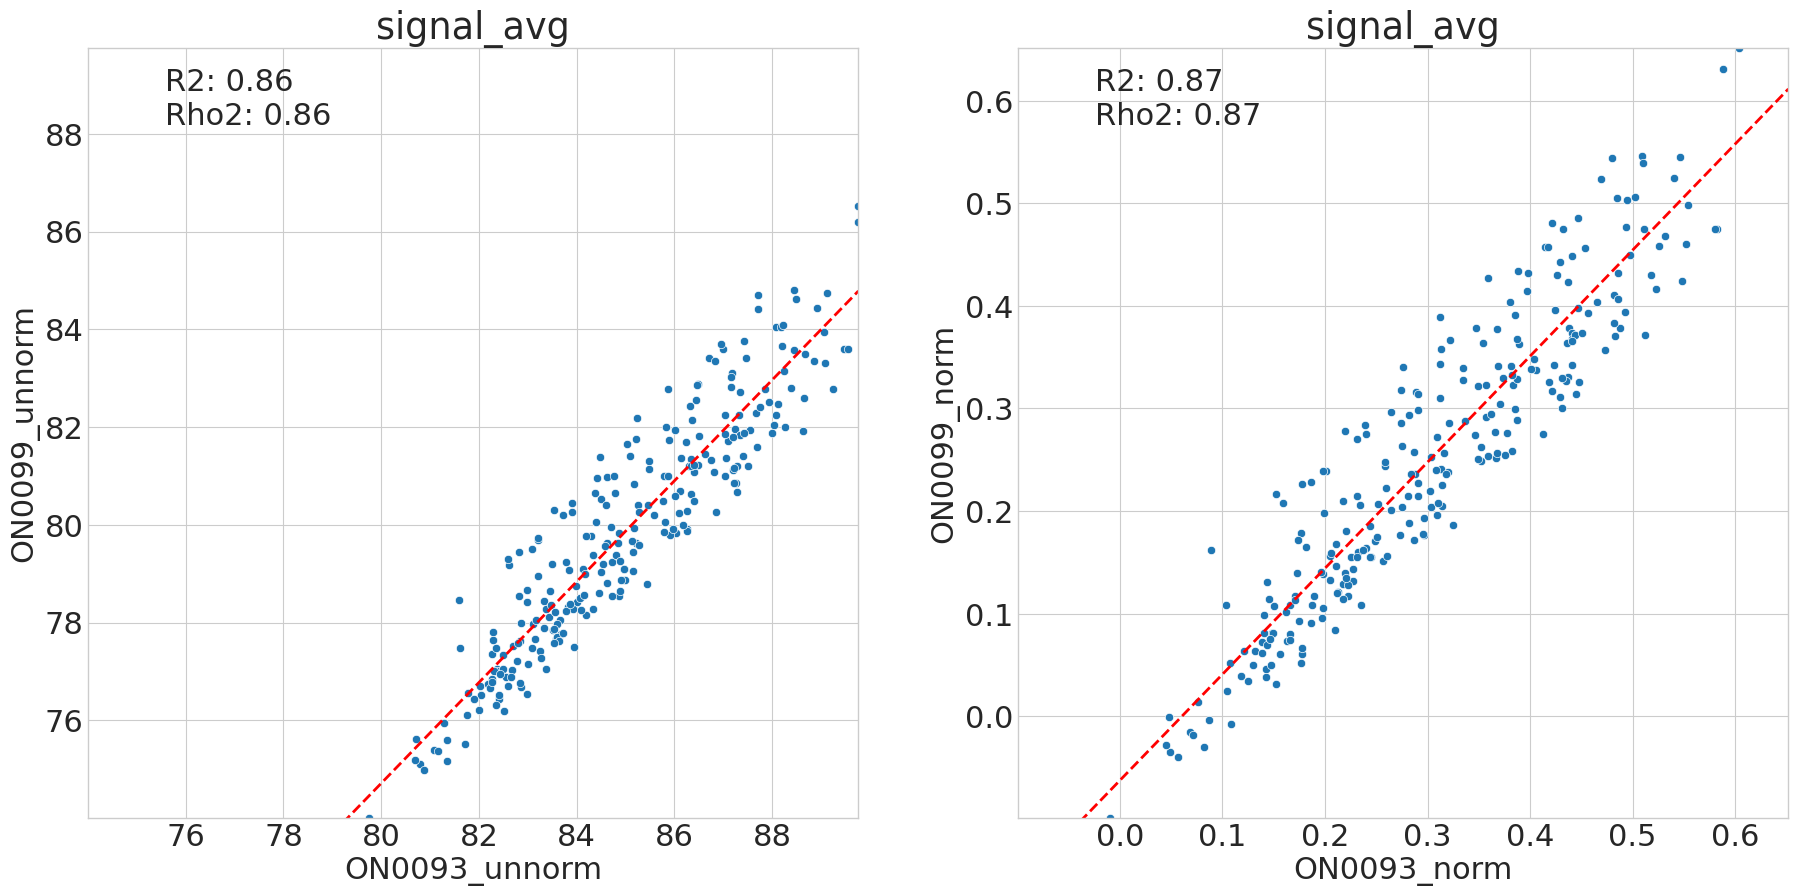

In [35]:
fig, axes = plt.subplots(1, 2, figsize = (22, 10))
plot_scatter(axes[0], dict_5mer, "ON0093_unnorm", "ON0099_unnorm", feature = "signal_avg")
plot_scatter(axes[1], dict_5mer, "ON0093_norm", "ON0099_norm", feature = "signal_avg")
plt.show()

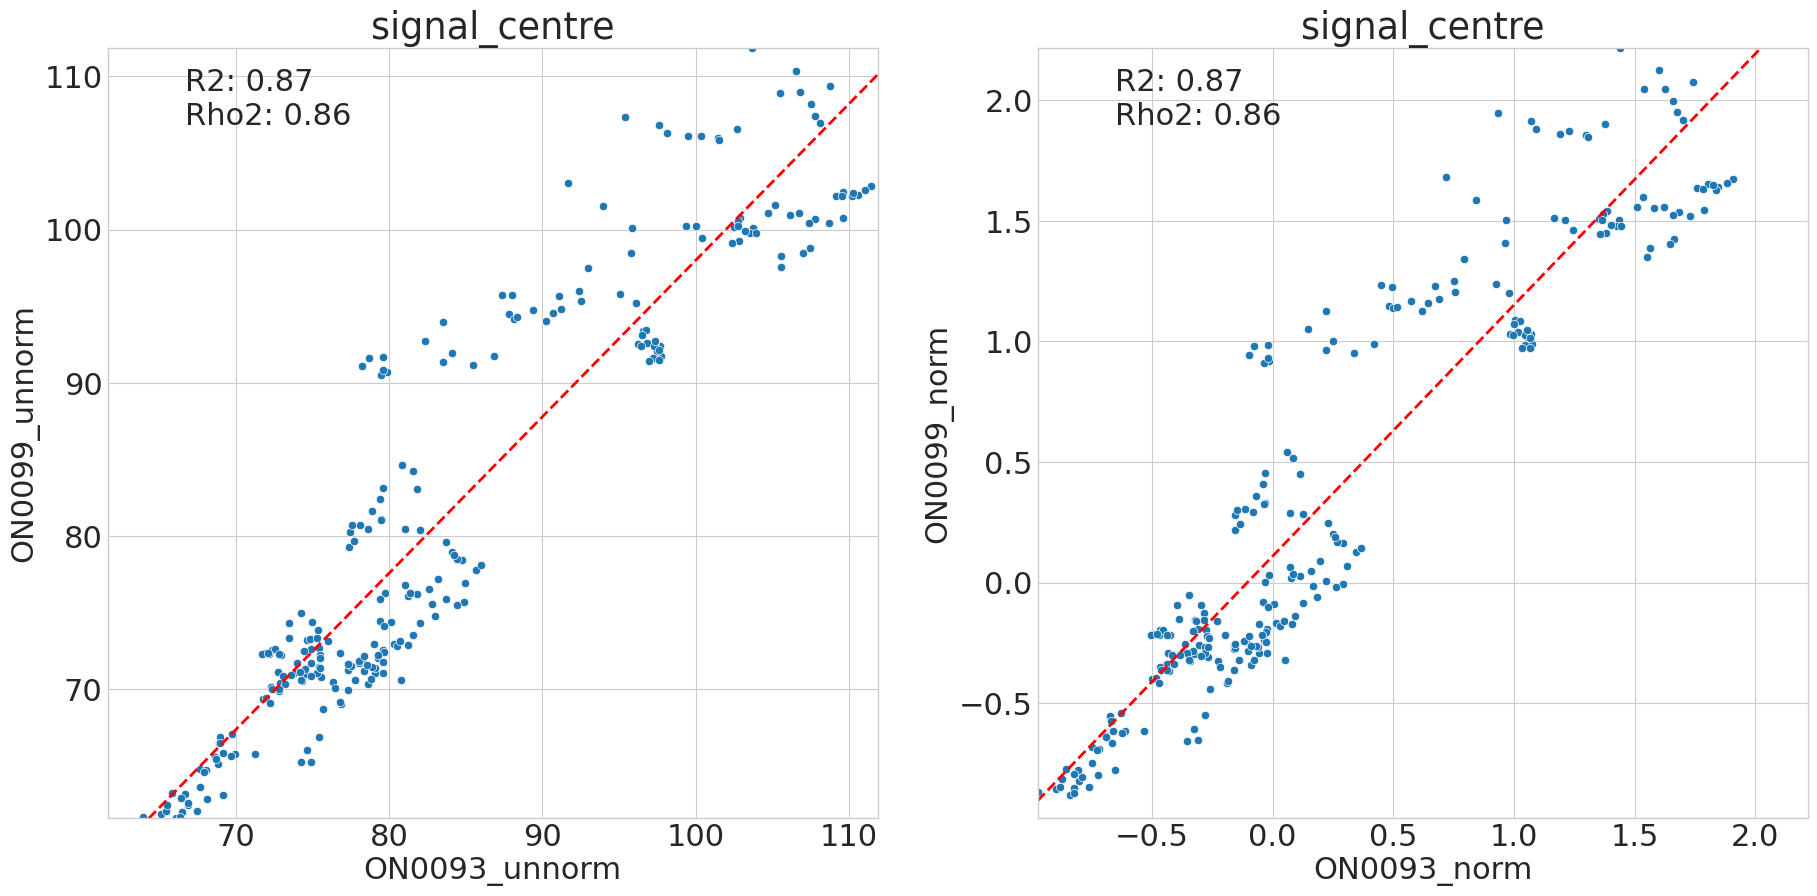

In [36]:
fig, axes = plt.subplots(1, 2, figsize = (22, 10))
plot_scatter(axes[0], dict_5mer, "ON0093_unnorm", "ON0099_unnorm", feature = "signal_centre")
plot_scatter(axes[1], dict_5mer, "ON0093_norm", "ON0099_norm",     feature = "signal_centre")
plt.show()

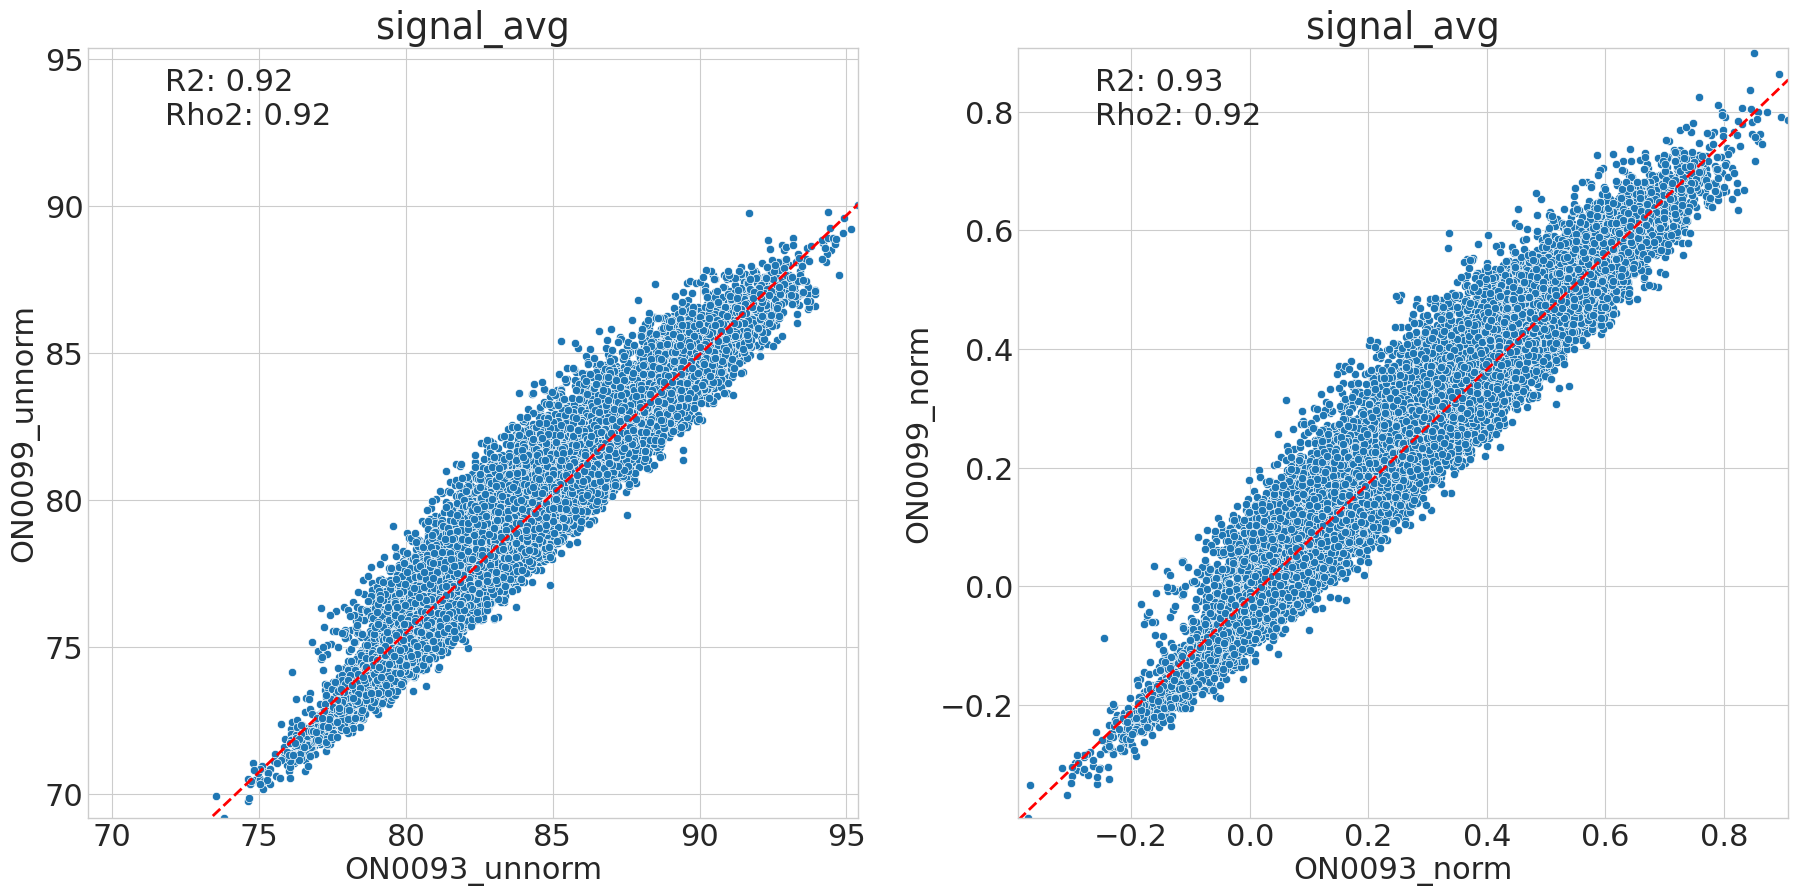

In [37]:
fig, axes = plt.subplots(1, 2, figsize = (22, 10))
plot_scatter(axes[0], dict_9mer, "ON0093_unnorm", "ON0099_unnorm", feature = "signal_avg")
plot_scatter(axes[1], dict_9mer, "ON0093_norm", "ON0099_norm", feature = "signal_avg")
plt.show()

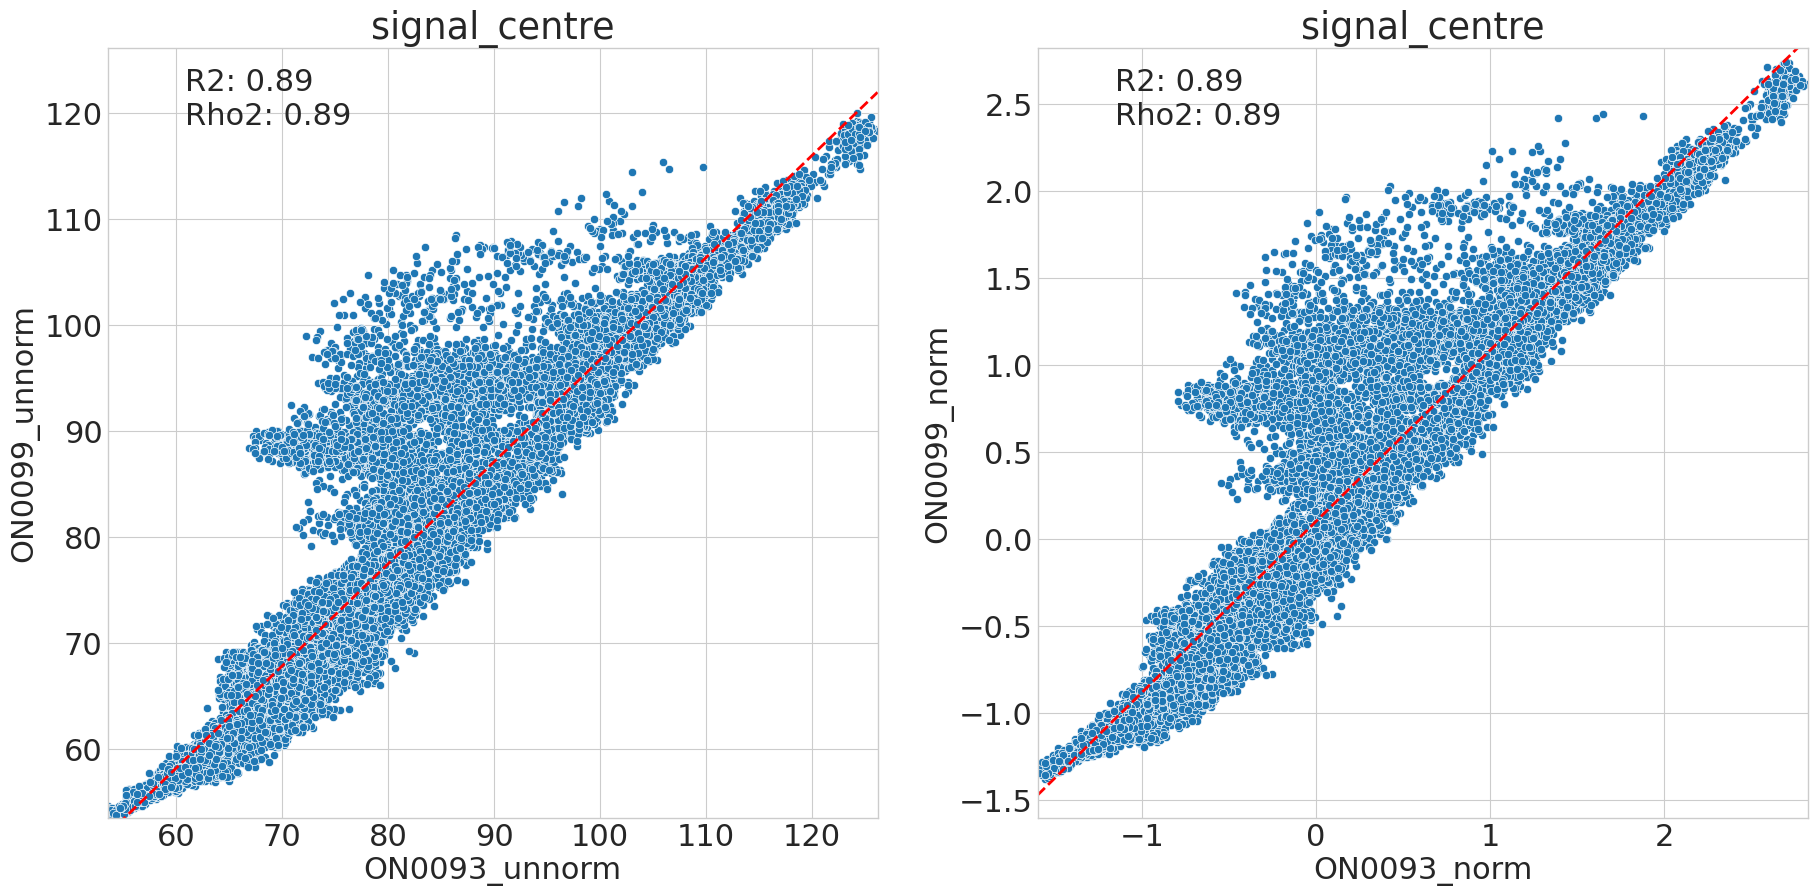

In [38]:
fig, axes = plt.subplots(1, 2, figsize = (22, 10))
plot_scatter(axes[0], dict_9mer, "ON0093_unnorm", "ON0099_unnorm", feature = "signal_centre")
plot_scatter(axes[1], dict_9mer, "ON0093_norm", "ON0099_norm",     feature = "signal_centre")
plt.show()

In [200]:
## Find motifs with largest discrepancy: ON0093 vs. ON0099
def get_discrepancy(df_dict, k1, k2, feature = "signal_avg", min_count = 100):
    merged_df = pd.merge(df_dict[k1][df_dict[k1]["count"] > min_count][[feature]],
                         df_dict[k2][df_dict[k2]["count"] > min_count][[feature]],
                         how = "inner", left_index = True, right_index = True).dropna()
    merged_df = merged_df[[f"{feature}_x", f"{feature}_y"]]
    merged_df.columns = [k1, k2]
    merged_df["discrepancy"] = (merged_df[k1] - merged_df[k2]).abs()
    merged_df = merged_df.sort_values("discrepancy", ascending = False)
    return merged_df

discrepancy_df = get_discrepancy(dict_9mer, "ON0093_norm", "ON0099_norm", feature = "signal_centre")
print(discrepancy_df)

           ON0093_norm  ON0099_norm   discrepancy
9mer                                             
AGACAGACG    -0.293305     1.623121  1.916426e+00
AAACAGACG    -0.243384     1.649628  1.893012e+00
GAACAGUCC    -0.460429     1.417194  1.877623e+00
CCAGAGUCC    -0.048483     1.816082  1.864565e+00
CAACAGAUG     0.017523     1.878333  1.860810e+00
...                ...          ...           ...
GGUAAUCCA    -0.961555    -0.961542  1.267452e-05
UGGUAUGCC    -0.457865    -0.457877  1.211402e-05
GCGCACUGC    -0.033575    -0.033566  8.872534e-06
GUCGACGGC    -0.201281    -0.201279  1.643737e-06
UACAAUGCC    -0.356716    -0.356715  6.309868e-07

[34228 rows x 3 columns]


In [50]:
def balance_motif(df1, df2, key = "5mer", min_count = 100):
    df1_motif_count = df1[key].value_counts()
    df2_motif_count = df2[key].value_counts()
    motif_count_df = pd.merge(df1_motif_count, df2_motif_count, left_index = True, right_index = True, how = "inner")
    motif_count_df["count_min"] = motif_count_df[["count_x", "count_y"]].min(axis = 1)
    motif_count_df = motif_count_df[motif_count_df["count_min"] > min_count]
    
    df1_grouped = df1.groupby(key)
    df2_grouped = df2.groupby(key)
    
    df1_new = []
    df2_new = []
    
    for motif, row in motif_count_df.iterrows():
        df1 = df1_grouped.get_group(motif)
        df2 = df2_grouped.get_group(motif)
        df1 = df1.sample(row["count_min"])
        df2 = df2.sample(row["count_min"])
        df1_new.append(df1)
        df2_new.append(df2)
    
    df1_new = pd.concat(df1_new)
    df2_new = pd.concat(df2_new)
    
    return df1_new, df2_new
    
    

In [51]:
ON0093_df_norm_balanced, ON0099_df_norm_balanced = balance_motif(ON0093_df_norm, ON0099_df_norm, key = "5mer", min_count = 100)
ON0093_df_unnorm_balanced, ON0099_df_unnorm_balanced = balance_motif(ON0093_df_unnorm, ON0099_df_unnorm, key = "5mer", min_count = 100)

       count_x  count_y  count_min
5mer                              
GCAAG   217890   202814     202814
GCAAC   192051   265762     192051
CCAAG   164460   204677     164460
GCAUG   155754   206015     155754
UCAAG   145966   134054     134054
...        ...      ...        ...
GGAGA     6573    36920       6573
AGAGA     5416    30830       5416
UGAGA     5339    42040       5339
UAAGU     5068    49797       5068
UAAGA     4524    35106       4524

[256 rows x 3 columns]
       count_x  count_y  count_min
5mer                              
GCAAG   217890   202814     202814
GCAAC   192051   265762     192051
CCAAG   164460   204677     164460
GCAUG   155754   206015     155754
UCAAG   145966   134054     134054
...        ...      ...        ...
GGAGA     6573    36920       6573
AGAGA     5416    30830       5416
UGAGA     5339    42040       5339
UAAGU     5068    49797       5068
UAAGA     4524    35106       4524

[256 rows x 3 columns]


In [54]:
## Plot KDE

def plot_kde(ax, df1, df2, feature = "signal_avg", label1 = None, label2 = None):
    sns.kdeplot(df1[feature], ax = ax, label = label1, color = "royalblue")
    sns.kdeplot(df2[feature], ax = ax, label = label2, color = "tomato")
    ax.set_title(feature)
    ax.legend()
    ## xlim at 1th, 99th percentile
    min_val = np.percentile(np.concatenate([df1[feature], df2[feature]]), 1)
    max_val = np.percentile(np.concatenate([df1[feature], df2[feature]]), 99)
    ax.set_xlim(min_val, max_val)
    

/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-

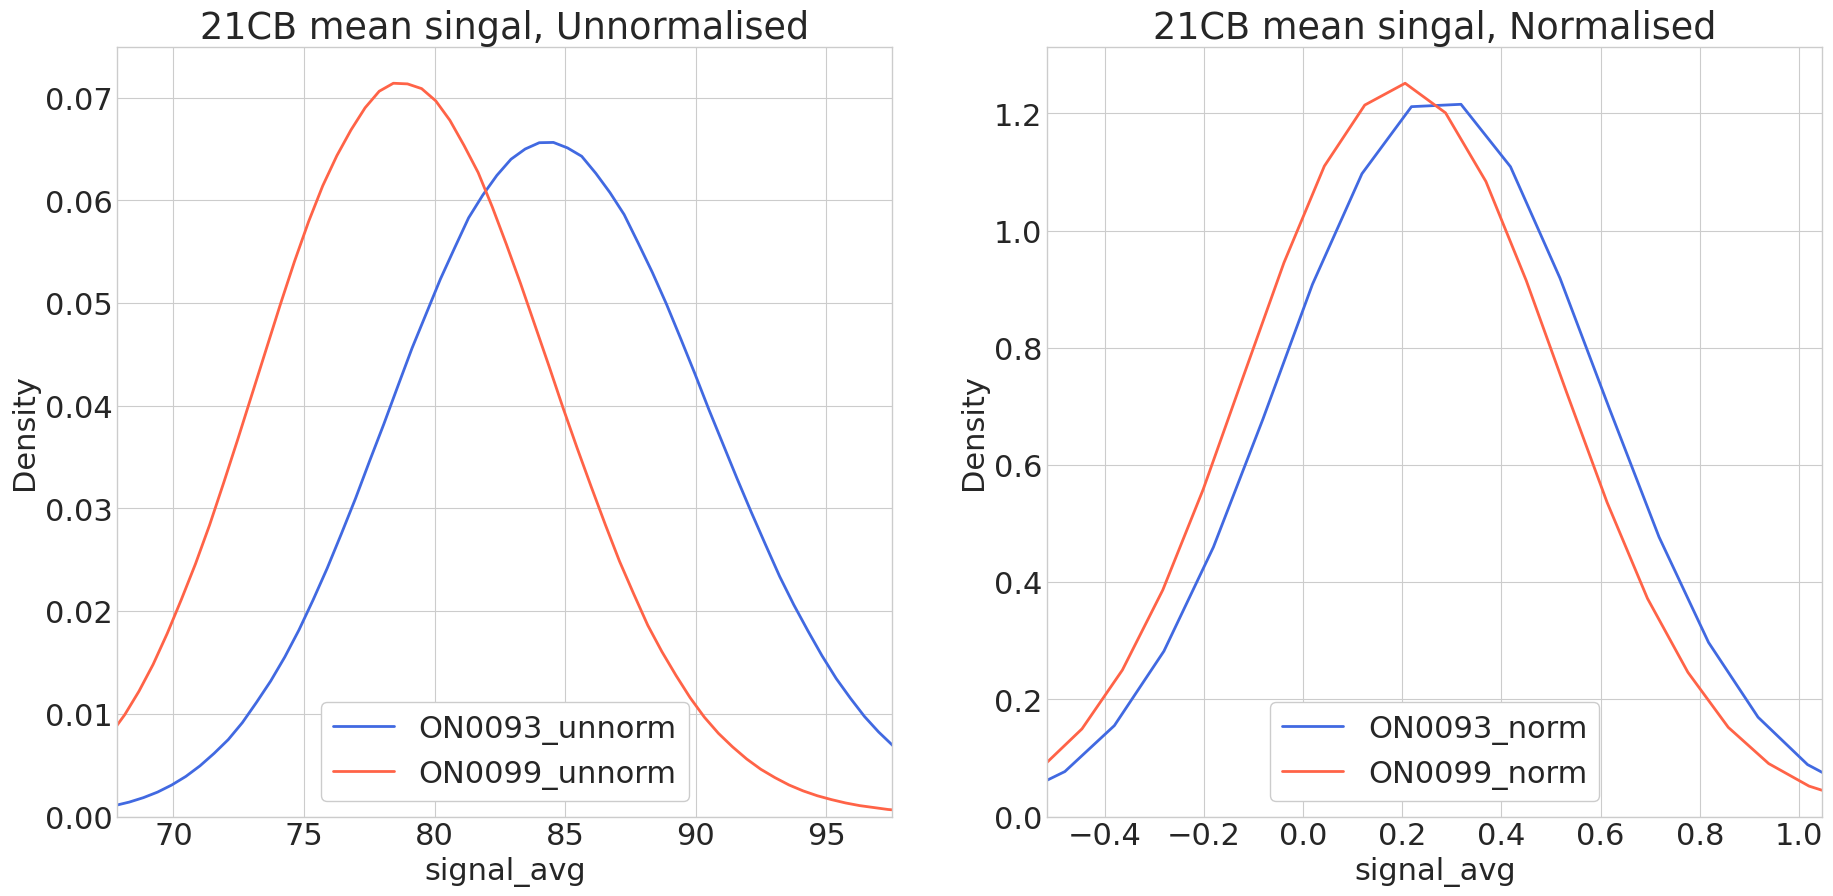

In [55]:

fig, axes = plt.subplots(1, 2, figsize = (22, 10))
plot_kde(axes[0], ON0093_df_unnorm_balanced, ON0099_df_unnorm_balanced, feature = "signal_avg", label1 = "ON0093_unnorm", label2 = "ON0099_unnorm")
plot_kde(axes[1], ON0093_df_norm_balanced, ON0099_df_norm_balanced, feature = "signal_avg", label1 = "ON0093_norm", label2 = "ON0099_norm")
axes[0].set_title("21CB mean singal, Unnormalised")
axes[1].set_title("21CB mean singal, Normalised")
plt.show()

In [58]:
model_9mer = dict_9mer["ON0093_norm"][dict_9mer["ON0093_norm"]["count"]>100]["signal_centre"]
print(model_9mer)

9mer
AAAAAAAGA    1.513412
AAAAAAAGC    0.899795
AAAAAAAGG    1.036547
AAAAAAAGU    1.184951
AAAAAACAA   -0.311933
               ...   
UUUUAUGCA   -0.319765
UUUUAUGCC   -0.498010
UUUUAUGCG   -0.384051
UUUUAUGCU   -0.134241
UUUUAUGUG   -0.244840
Name: signal_centre, Length: 34513, dtype: float64


In [157]:
ON0099_data_path = "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0099/result/dorado-070/intermediates/segmented_tokenized/token_dwell_bq"
ON0099_data_paths = glob.glob(f"{ON0099_data_path}/*.npz")

ON0093_data_path = "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0093/ON0093/result/dorado-070/intermediates/segmented_tokenized/token_dwell_bq"
ON0093_data_paths = glob.glob(f"{ON0093_data_path}/*.npz")

In [159]:
def read_data(data_paths):
    keys = ["kmer_token", "segment_len_arr", "signal_token"]
    data = {key: [] for key in keys}
    for data_path in tqdm.tqdm(data_paths):
        with np.load(data_path) as f:
            for key in keys:
                data[key].append(f[key])
    data = {key: np.concatenate(data[key]) for key in keys}
    return data

In [272]:
ON0093_data = read_data(np.random.choice(ON0093_data_paths,10000))
ON0099_data = read_data(np.random.choice(ON0099_data_paths,10000))

  1%|██                                                                                                                                                         | 136/10000 [00:05<06:19, 26.00it/s]

KeyboardInterrupt



In [167]:
def get_signal_centre(segment_len_arr, signal_arr):
    return np.array_split(signal_arr[12:-12],np.cumsum(segment_len_arr*6))[8].mean()

def get_signal_centre_df(data):
    motif_list = []
    signal_centre_list = []
    
    for k in tqdm.tqdm(range(len(data["kmer_token"]))):
        motif = "".join([chr(x) for x in data["kmer_token"][k][6:-6]])
        signal_centre = get_signal_centre(data["segment_len_arr"][k], data["signal_token"][k])
        motif_list.append(motif)
        signal_centre_list.append(signal_centre)
    
    df = pd.DataFrame({"motif": motif_list, "signal_centre": signal_centre_list})
    return df
    

In [168]:
ON0093_signal_df = get_signal_centre_df(ON0093_data)
ON0099_signal_df = get_signal_centre_df(ON0099_data)

  0%|▍                                                                                                                                                     | 2521/779584 [00:00<00:59, 13094.39it/s]/tmp/ipykernel_65981/3788425444.py:2: RuntimeWarning: Mean of empty slice.
  return np.array_split(signal_arr[12:-12],np.cumsum(segment_len_arr*6))[8].mean()
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 892358/892358 [00:49<00:00, 18135.86it/s]


In [170]:
ON0093_signal_df["index_ON0093"] = ON0093_signal_df.index
ON0099_signal_df["index_ON0099"] = ON0099_signal_df.index

ON0093_signal_df.rename(columns = {"signal_centre": "signal_centre_ON0093"}, inplace = True)
ON0099_signal_df.rename(columns = {"signal_centre": "signal_centre_ON0099"}, inplace = True)

In [174]:
motif_common = np.intersect1d(ON0093_signal_df["motif"].unique(), ON0099_signal_df["motif"].unique())
print(motif_common)

['AAAAAAAAA' 'AAAAAAAAC' 'AAAAAAAAG' ... 'UUUUAUUUC' 'UUUUAUUUG'
 'UUUUAUUUU']


In [179]:
ON0099_grouped = ON0099_signal_df.groupby("motif")
ON0093_grouped = ON0093_signal_df.groupby("motif")

idx_list = []

for motif in tqdm.tqdm(motif_common):
    ON0093_df = ON0093_grouped.get_group(motif)
    ON0099_df = ON0099_grouped.get_group(motif)
    try:
        model_signal = model_9mer[motif]
    except:
        continue
    
    ## Max discrepancy for ON0099, Min discrepancy for ON0093
    ON0099_max = ON0099_df.loc[(ON0099_df["signal_centre_ON0099"] - model_signal).abs().idxmax()]
    ON0093_min = ON0093_df.loc[(ON0093_df["signal_centre_ON0093"] - model_signal).abs().idxmin()]
    idx_list.append([motif, ON0099_max["index_ON0099"], ON0093_min["index_ON0093"], model_signal, ON0099_max["signal_centre_ON0099"], ON0093_min["signal_centre_ON0093"]])

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 63845/63845 [00:40<00:00, 1581.48it/s]


In [180]:
discrepancy_df = pd.DataFrame(idx_list, columns = ["motif", "index_ON0099", "index_ON0093", "model_signal", "signal_centre_ON0099", "signal_centre_ON0093"])
print(discrepancy_df)

           motif  index_ON0099  index_ON0093  model_signal  \
0      AAAAAAAGA        821954        226320      1.513412   
1      AAAAAAAGC        837578        741082      0.899795   
2      AAAAAAAGG        477653        547802      1.036547   
3      AAAAAAAGU         93122        649946      1.184951   
4      AAAAAACAA        372128        650907     -0.311933   
...          ...           ...           ...           ...   
34418  UUUUAUGCA        814853        709602     -0.319765   
34419  UUUUAUGCC        340155        372217     -0.498010   
34420  UUUUAUGCG        678696         15613     -0.384051   
34421  UUUUAUGCU        250048        370373     -0.134241   
34422  UUUUAUGUG        334128        701583     -0.244840   

       signal_centre_ON0099  signal_centre_ON0093  
0                  1.071762              1.597545  
1                  1.244802              0.904834  
2                  0.833480              1.012885  
3                  1.331904              1.2261

In [199]:
print(ON0099_signal_df["signal_centre_ON0099"].describe())
print(ON0093_signal_df["signal_centre_ON0093"].describe())

count    892356.000000
mean          0.271796
std           0.986452
min          -9.371342
25%          -0.498001
50%           0.043828
75%           1.031386
max          15.184535
Name: signal_centre_ON0099, dtype: float64
count    779580.000000
mean          0.074311
std           0.967687
min         -10.432202
25%          -0.623083
50%          -0.172154
75%           0.694260
max          20.355295
Name: signal_centre_ON0093, dtype: float64


In [188]:
discrepancy_df["deviation"] = (discrepancy_df["signal_centre_ON0099"] - discrepancy_df["model_signal"]).abs()
discrepancy_df = discrepancy_df.sort_values("deviation", ascending = False).reset_index(drop = True)

In [224]:
print(discrepancy_df[:10])

           ON0093_norm  ON0099_norm  discrepancy
9mer                                            
AGACAGACG    -0.293305     1.623121     1.916426
AAACAGACG    -0.243384     1.649628     1.893012
GAACAGUCC    -0.460429     1.417194     1.877623
CCAGAGUCC    -0.048483     1.816082     1.864565
CAACAGAUG     0.017523     1.878333     1.860810
CUACAGUCC    -0.378827     1.459967     1.838794
CAGGAGUCC    -0.118653     1.715138     1.833791
UGACAGACG    -0.288396     1.543933     1.832329
GGACAGUCC    -0.406335     1.420777     1.827112
GCUGAGUCC    -0.182018     1.638651     1.820669


In [206]:
print(ON0099_grouped.get_group("AGACAGACG"))

            motif  signal_centre_ON0099  index_ON0099
67064   AGACAGACG              2.356354         67064
88516   AGACAGACG              2.279344         88516
111077  AGACAGACG              1.963393        111077
126592  AGACAGACG              1.610747        126592
386683  AGACAGACG             -1.308668        386683
455155  AGACAGACG              2.282035        455155
470874  AGACAGACG              2.115928        470874
648776  AGACAGACG              2.329246        648776
649968  AGACAGACG              0.004578        649968


In [257]:
def plot_signal(ax, data, k):
    segment_len_arr = data["segment_len_arr"][k]
    signal_arr = data["signal_token"][k]
    motif = data["kmer_token"][k]
    motif = "".join([chr(i) for i in motif])[2:-2]
    end = int(np.sum(segment_len_arr)*6+12)
    signal_arr = signal_arr[12:end]
    ax.plot(signal_arr)
    ## Vline at the segment_len_arr 
    for n, i in enumerate(np.concatenate([[0],np.cumsum(segment_len_arr*6).astype(int)])):
        ax.axvline(i, color="k")
        if n < len(segment_len_arr):
            ax.text(i, 1.5, f"{n+1}\n{motif[n]}")
    ax.set_ylim(-3,3)
    

In [258]:
def plot_motif( motif):
    ON0099_sample = ON0099_grouped.get_group(motif)
    ON0093_sample = ON0093_grouped.get_group(motif)
    ON0099_sample = ON0099_sample.sample(5)
    ON0093_sample = ON0093_sample.sample(5)
    fig, axes = plt.subplots(5, 2, figsize = (30,20))
    for i in range(5):
        plot_signal(axes[i, 0], ON0093_data, ON0093_sample.index[i])
        plot_signal(axes[i, 1], ON0099_data, ON0099_sample.index[i])
    plt.show()
    
    


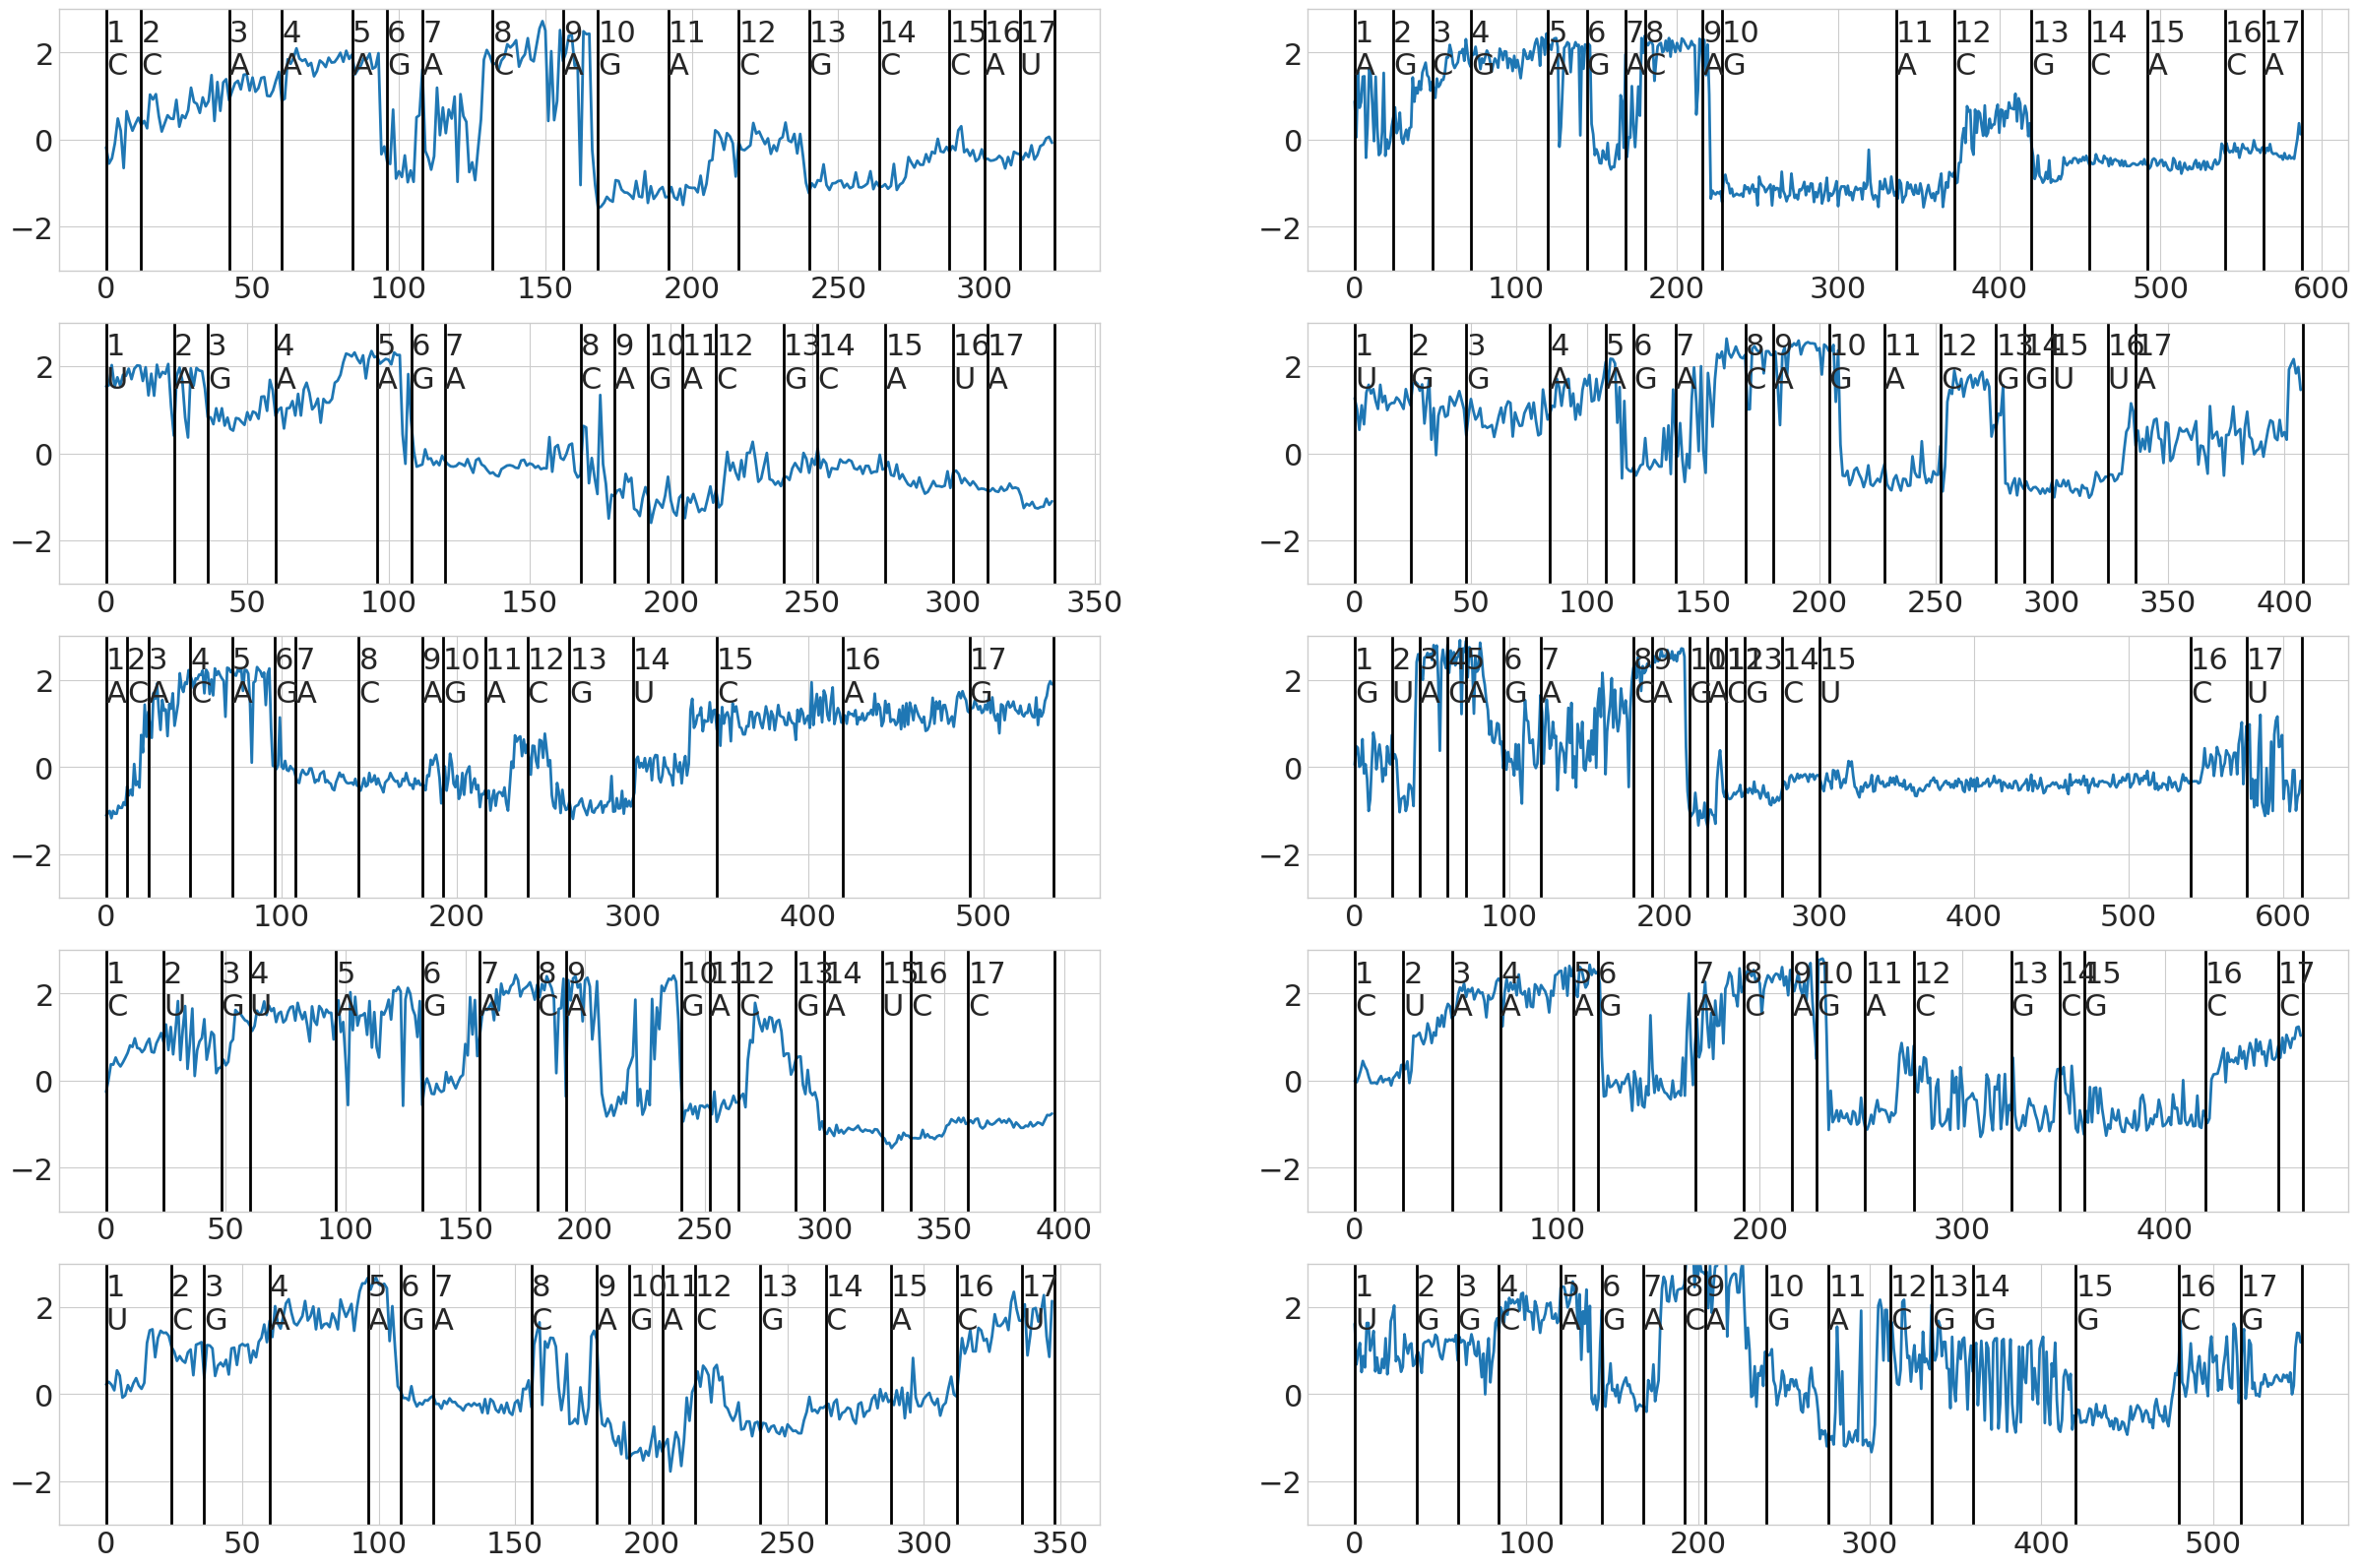

In [259]:
plot_motif("AGACAGACG")

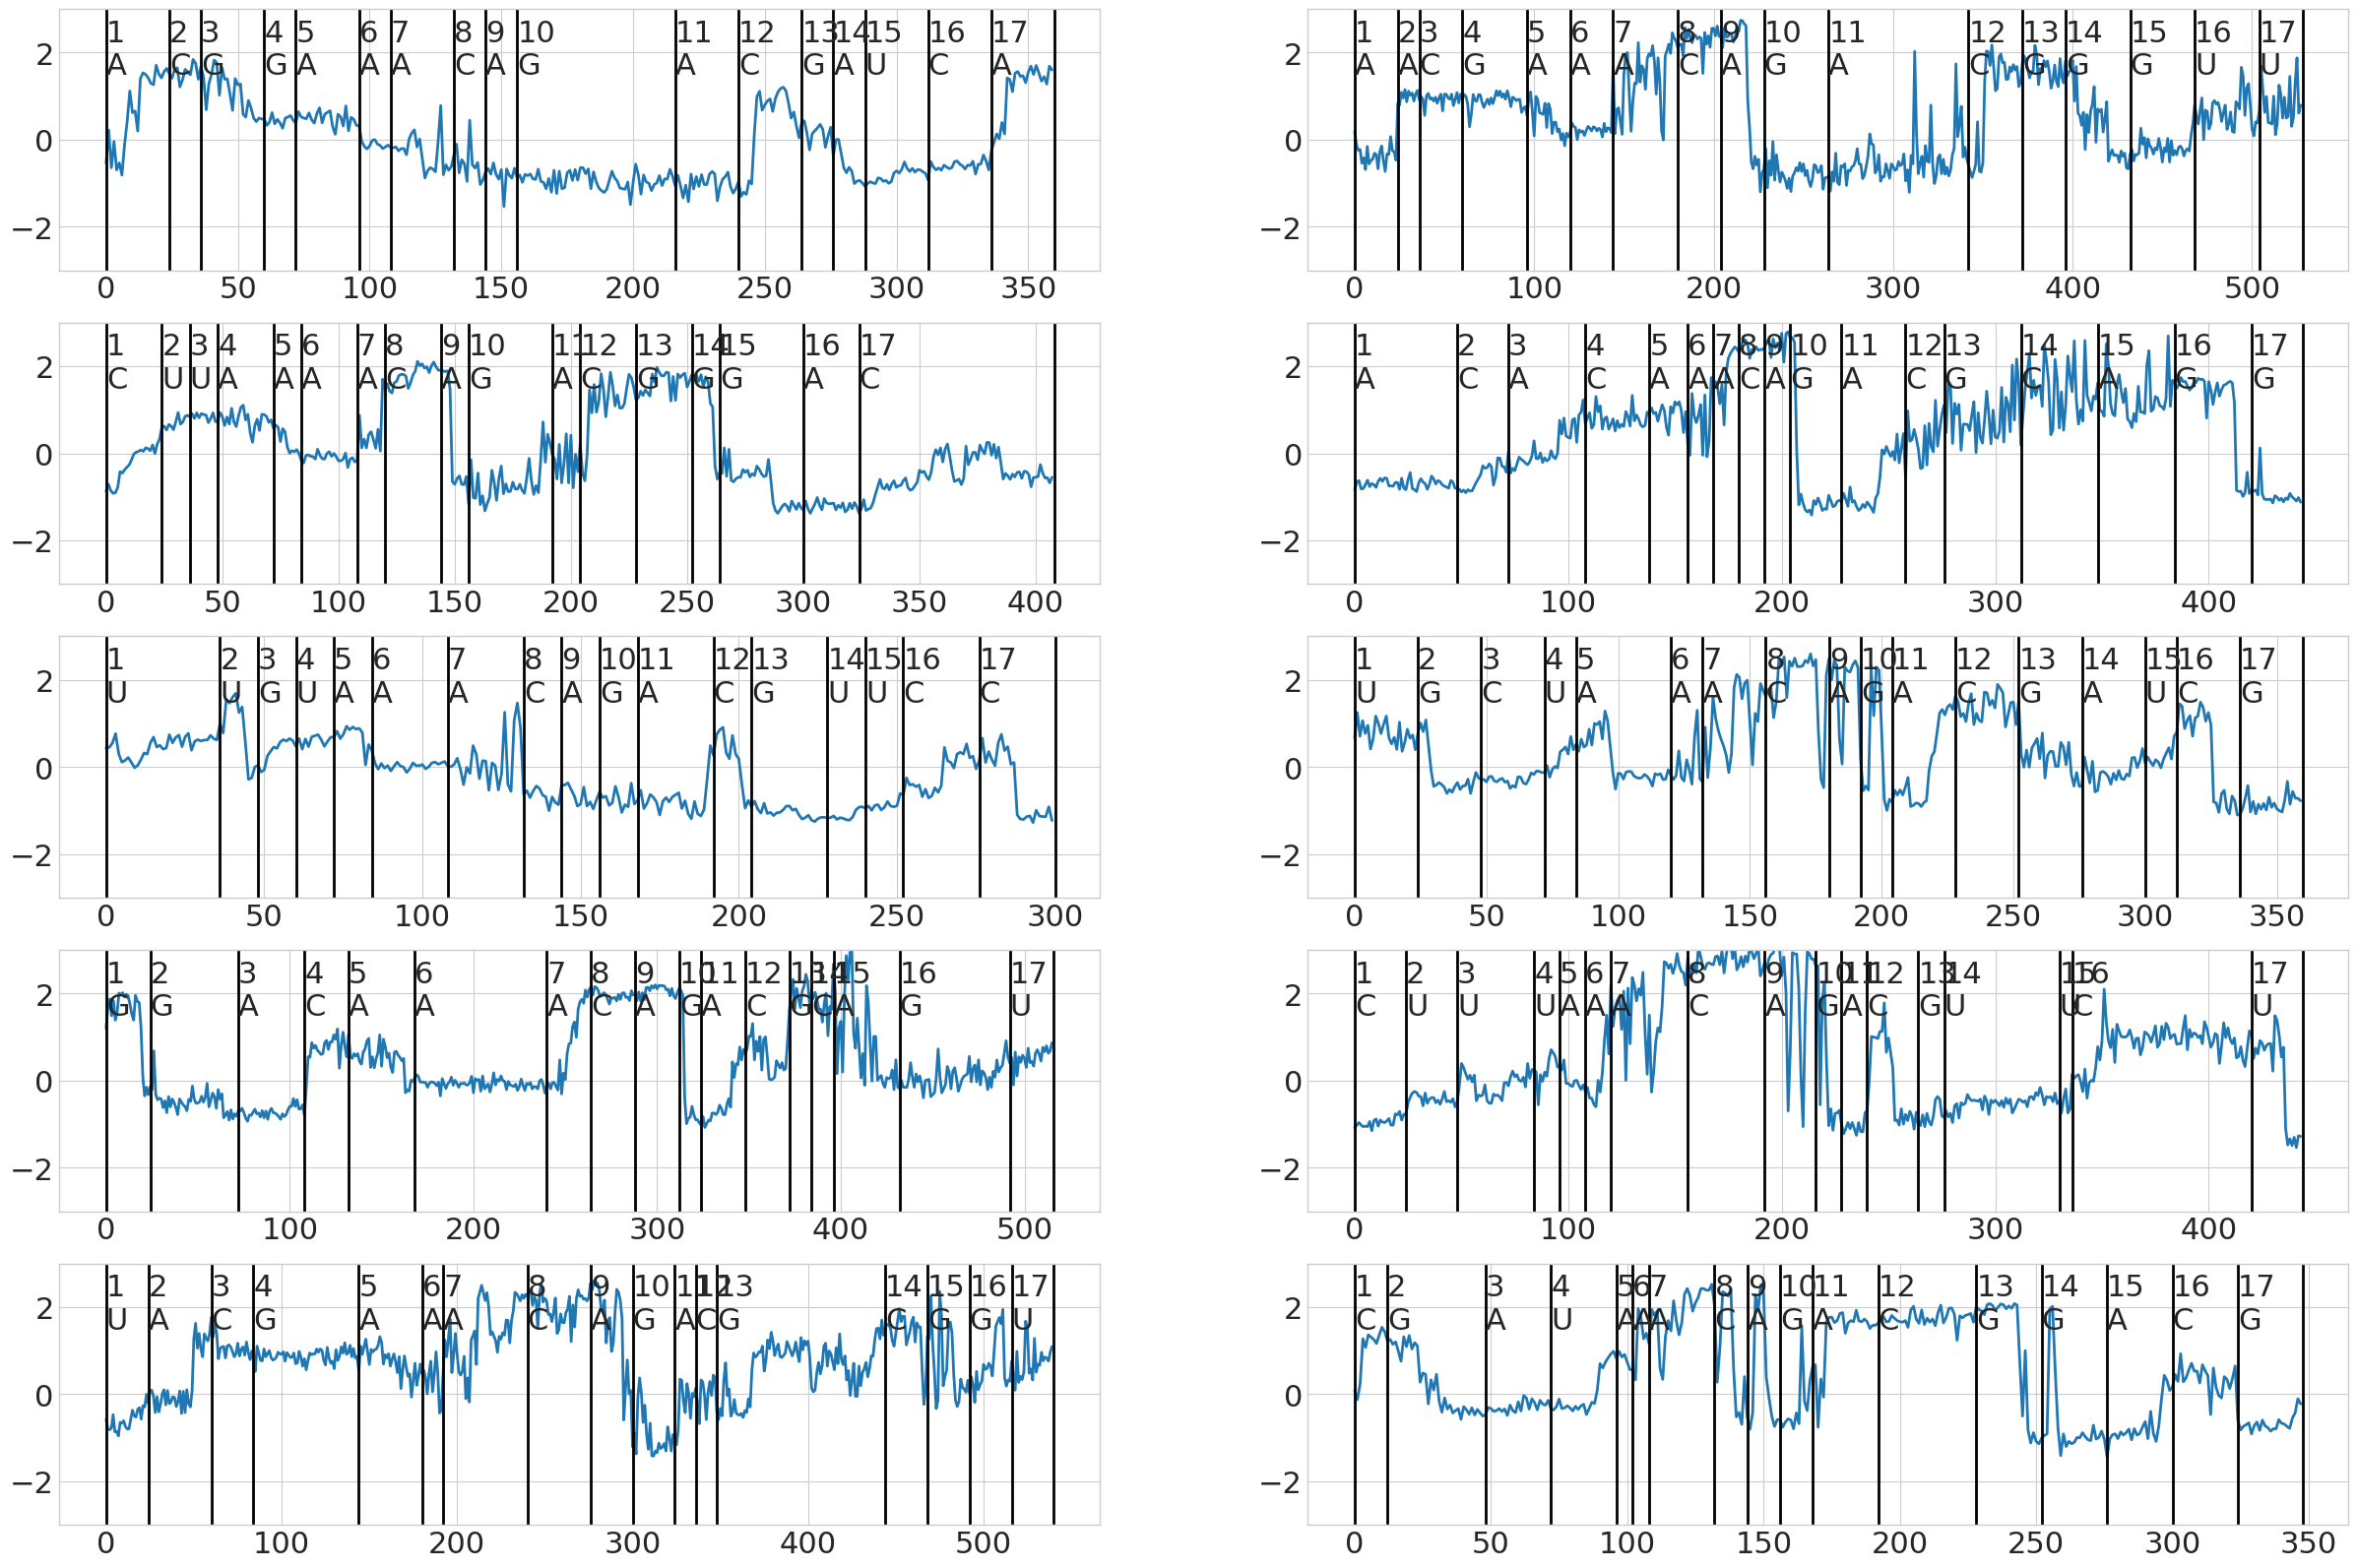

In [260]:
plot_motif("AAACAGACG")

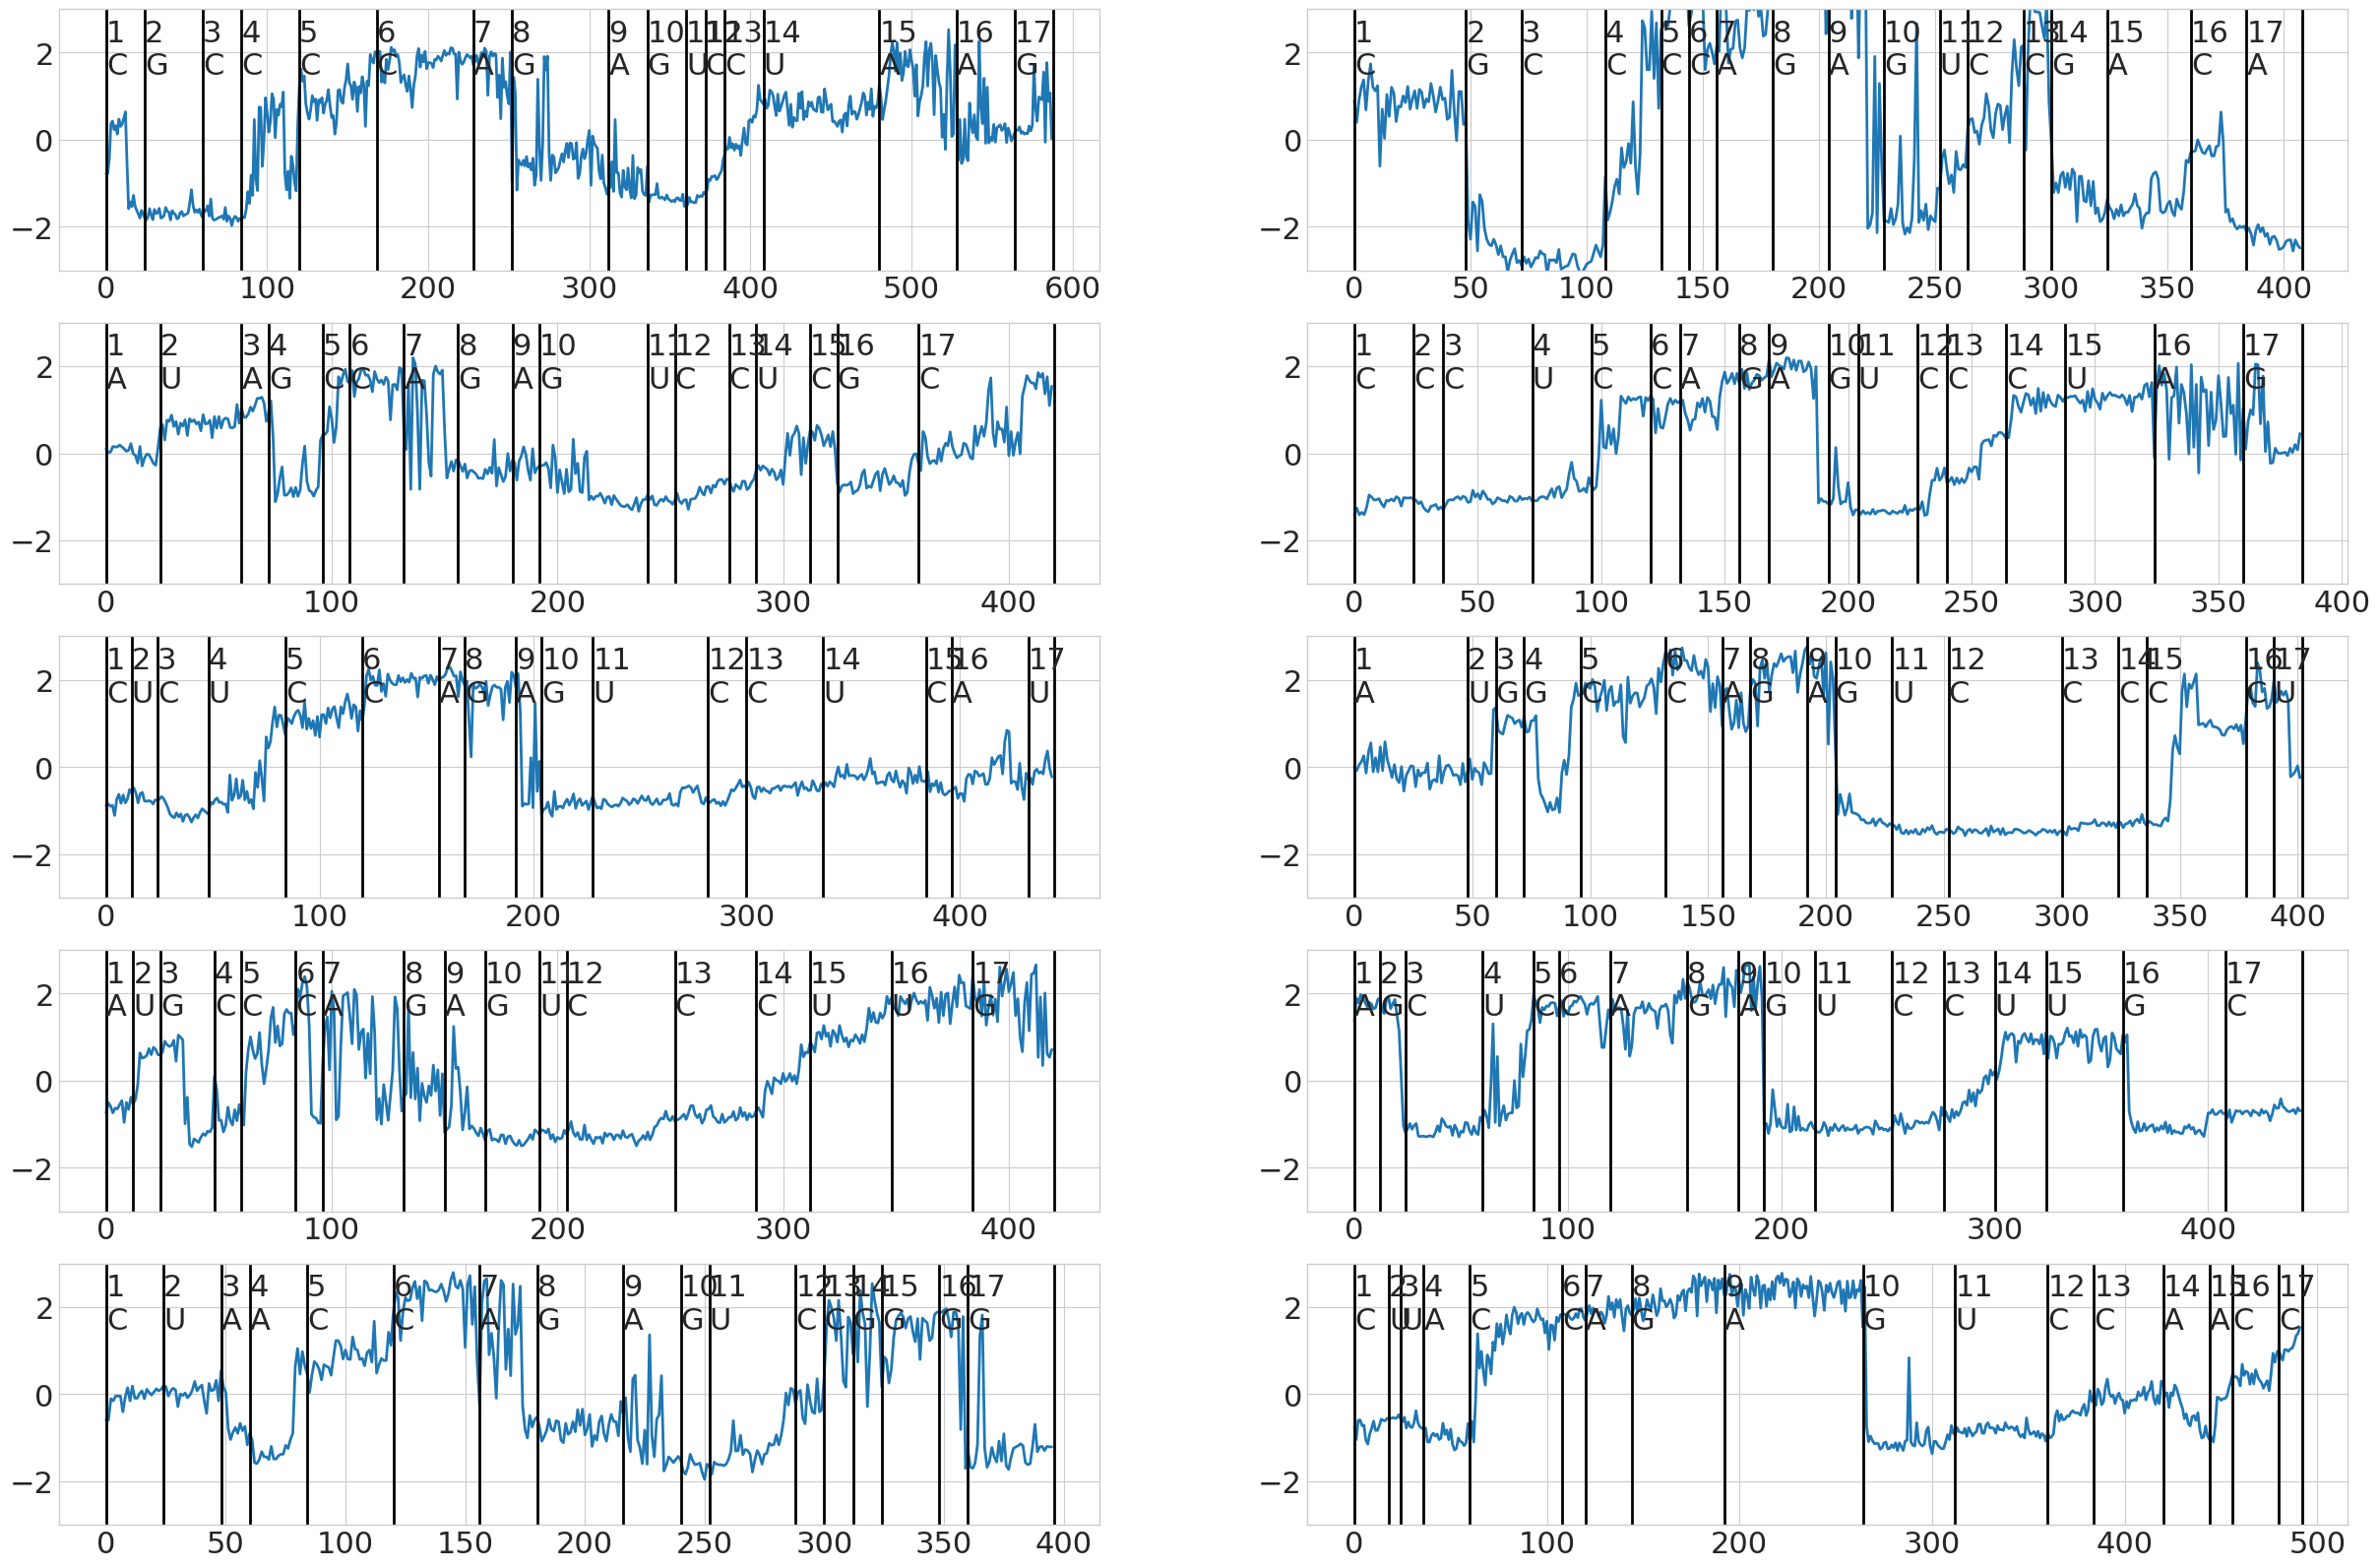

In [261]:
plot_motif("CCAGAGUCC")

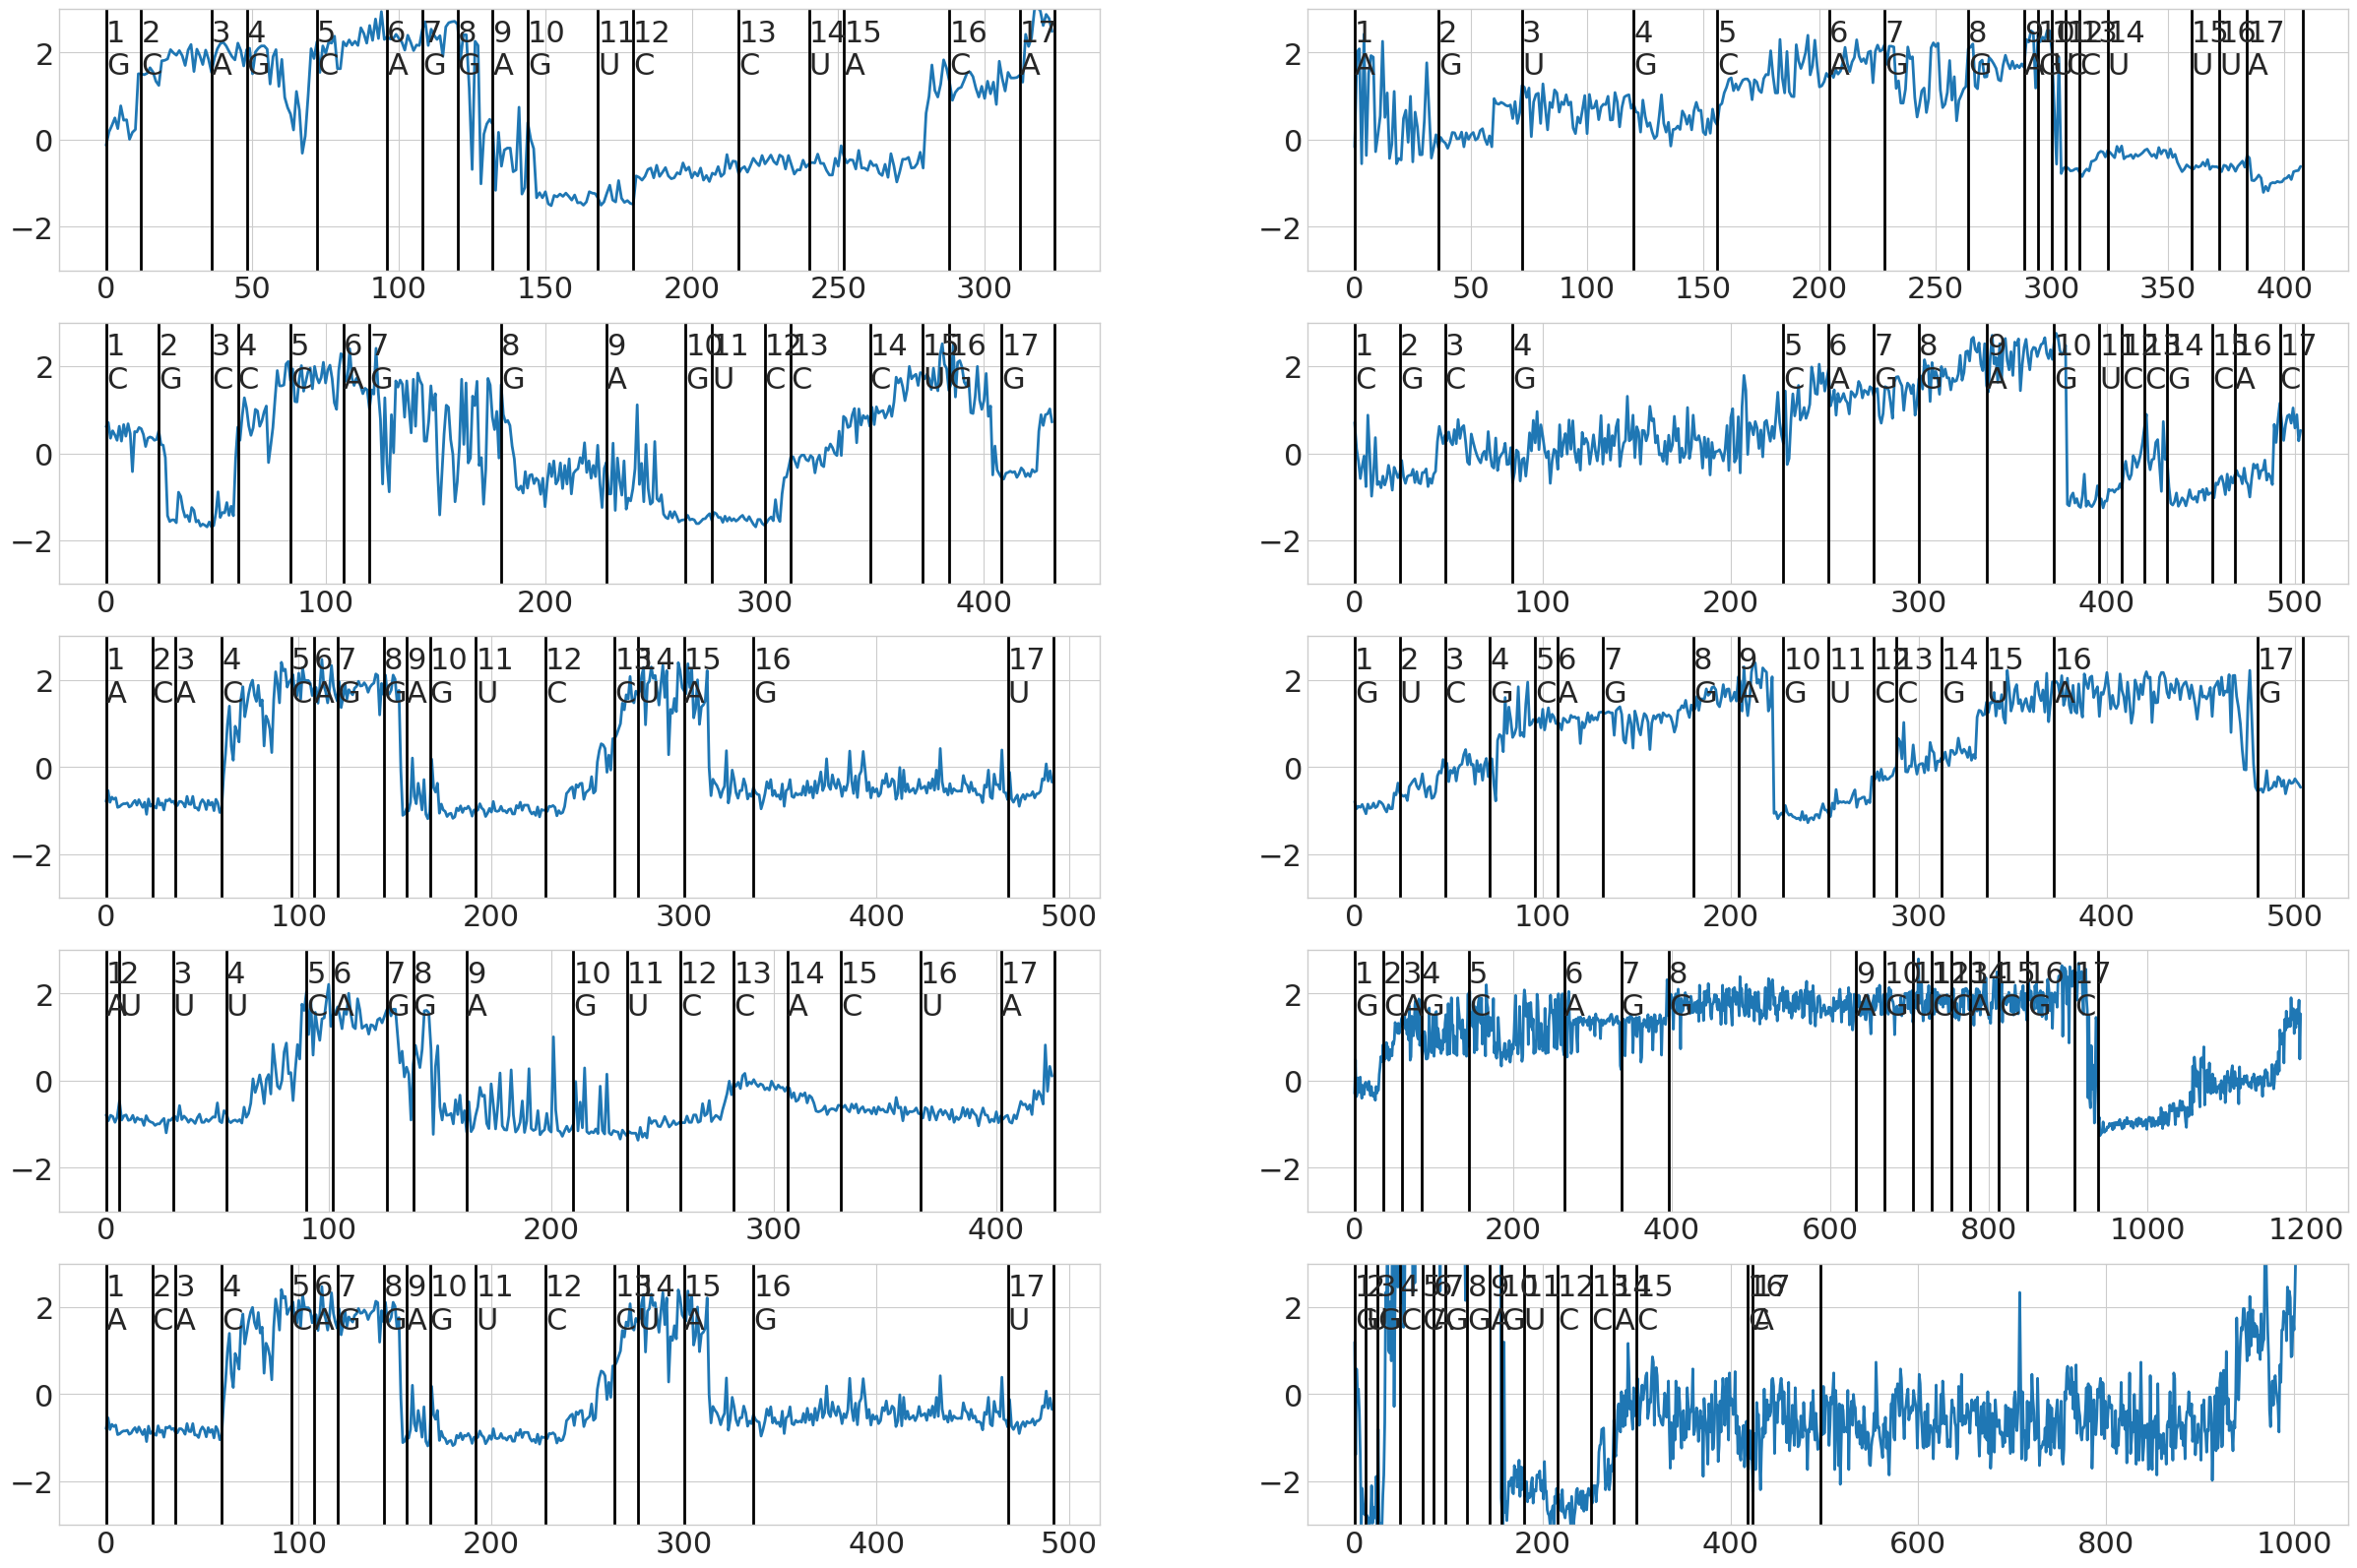

CAGGAGUCC


In [262]:
motif = discrepancy_df.index[6]
plot_motif(motif)
print(motif)

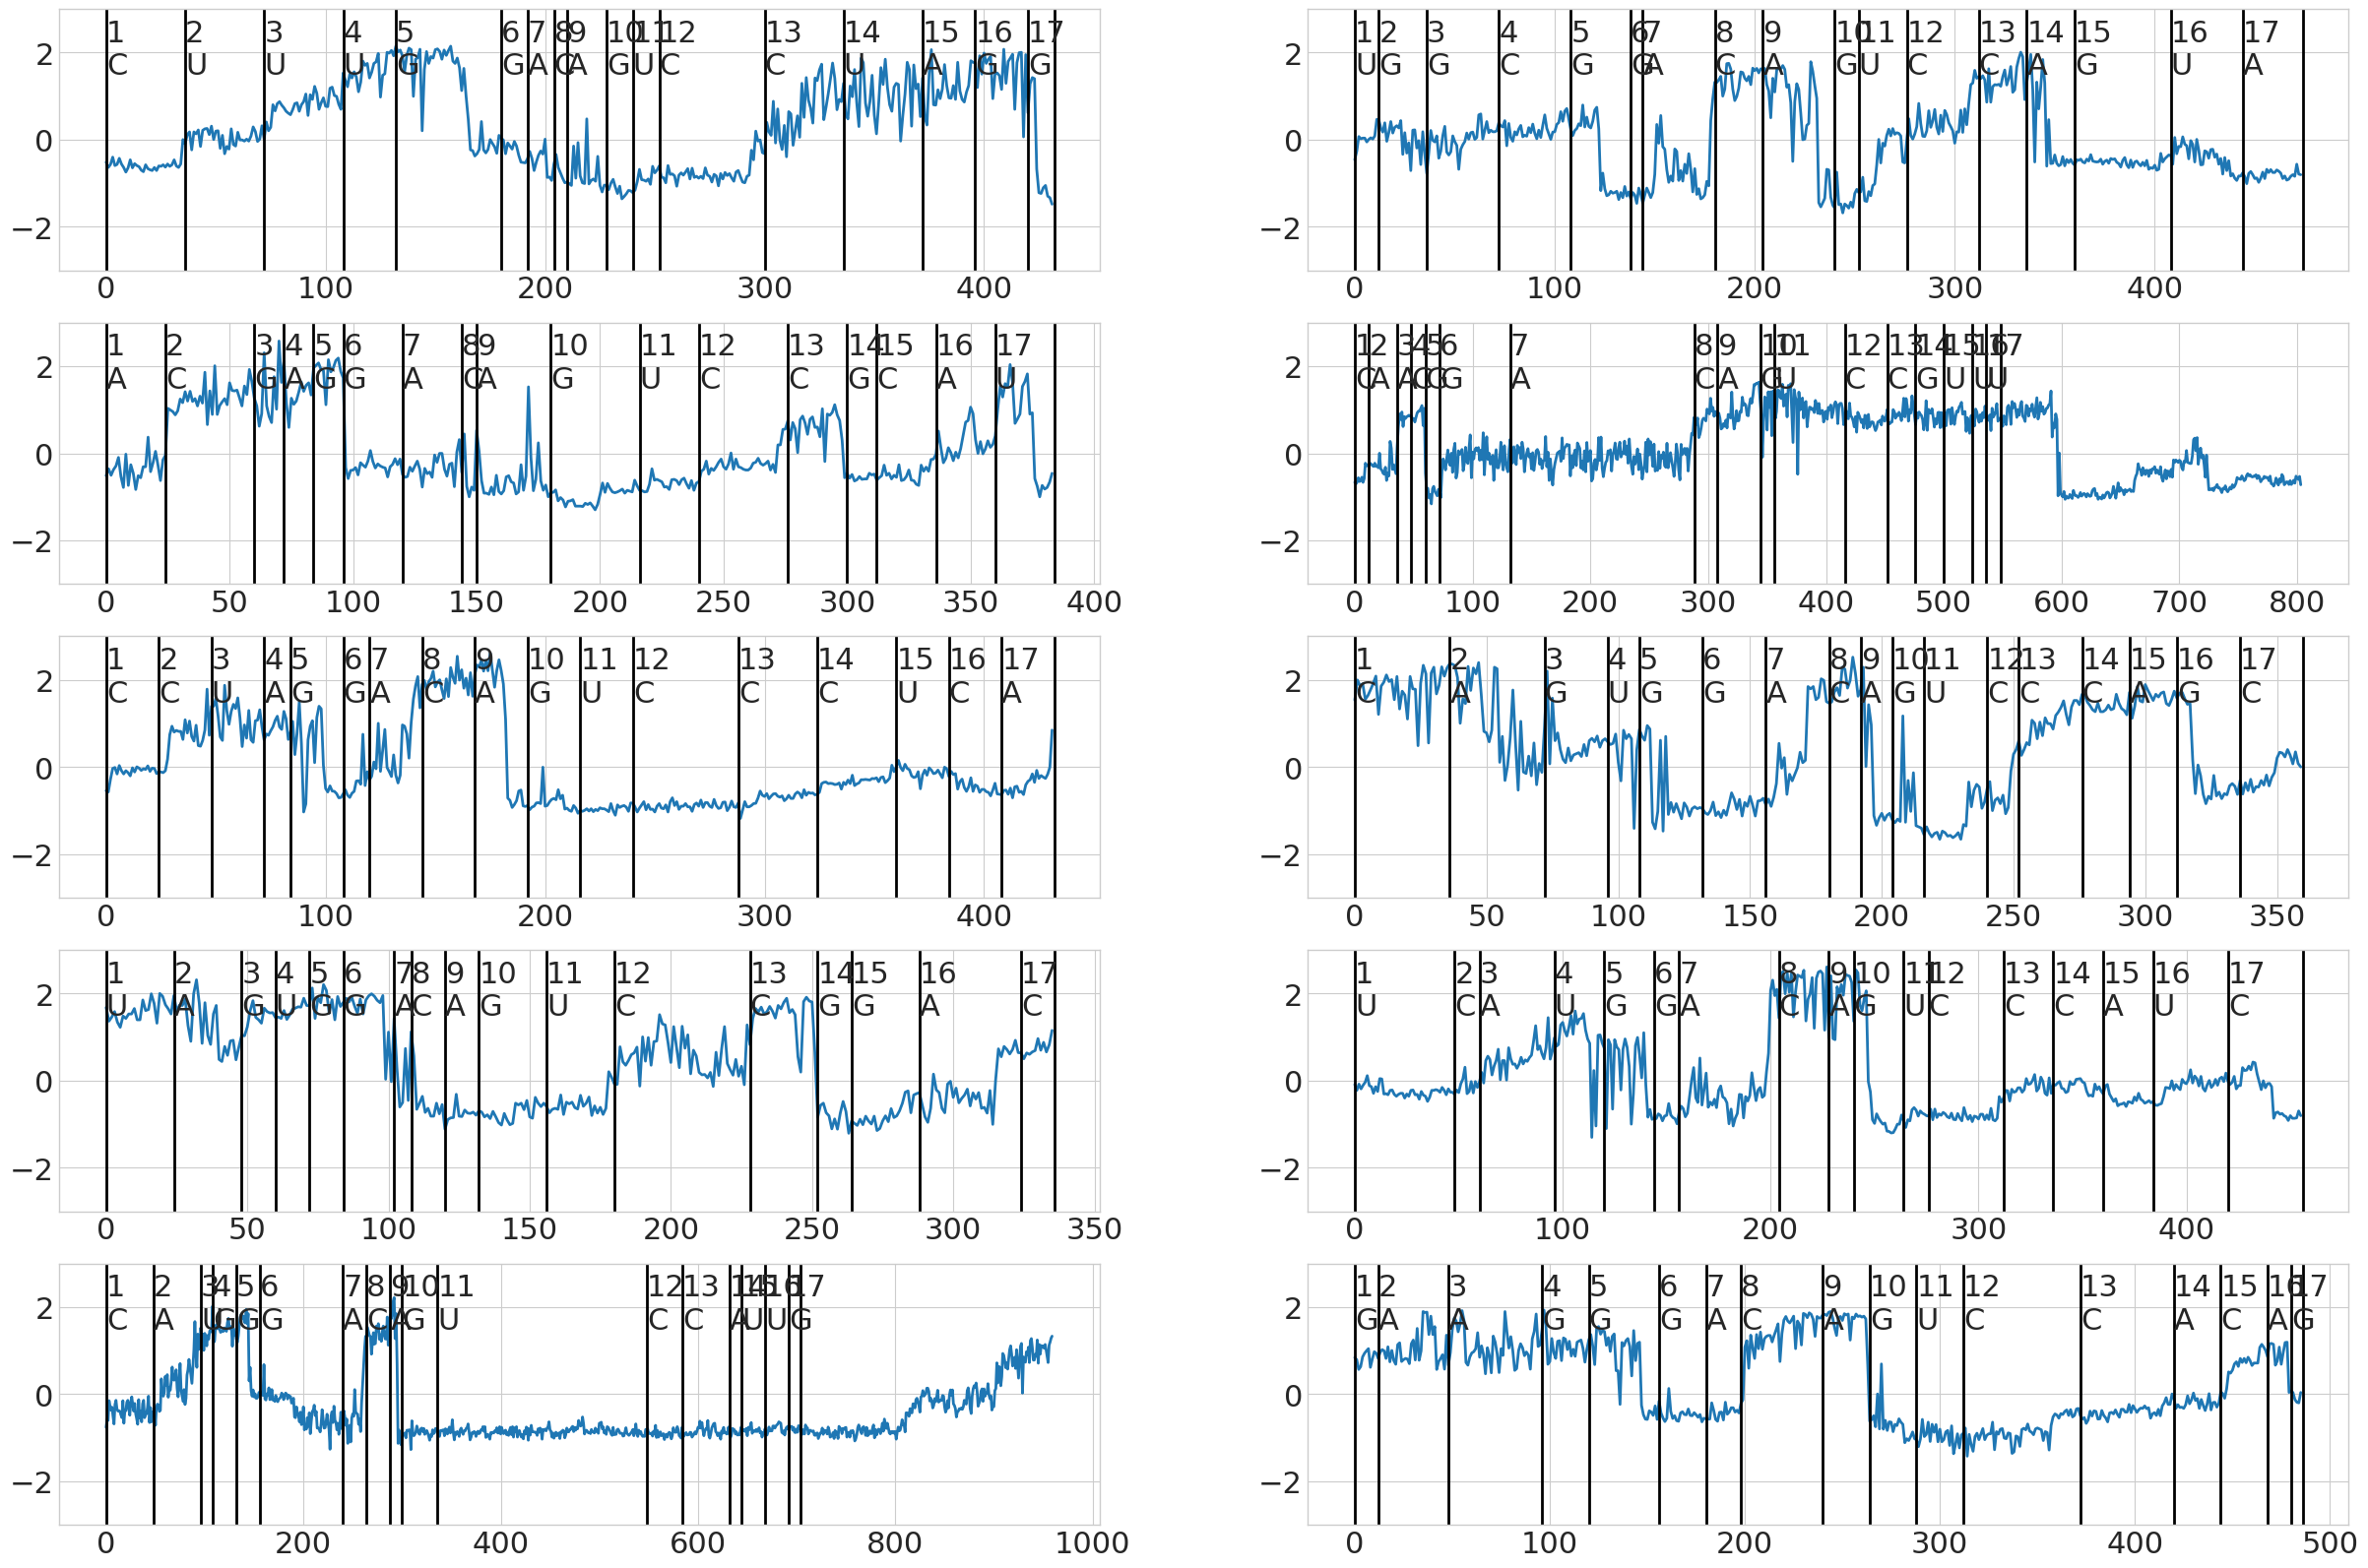

GGACAGUCC


In [264]:
motif = discrepancy_df.index[8]
plot_motif(motif)
print(motif)

In [265]:
print(discrepancy_df)

           ON0093_norm  ON0099_norm   discrepancy
9mer                                             
AGACAGACG    -0.293305     1.623121  1.916426e+00
AAACAGACG    -0.243384     1.649628  1.893012e+00
GAACAGUCC    -0.460429     1.417194  1.877623e+00
CCAGAGUCC    -0.048483     1.816082  1.864565e+00
CAACAGAUG     0.017523     1.878333  1.860810e+00
...                ...          ...           ...
GGUAAUCCA    -0.961555    -0.961542  1.267452e-05
UGGUAUGCC    -0.457865    -0.457877  1.211402e-05
GCGCACUGC    -0.033575    -0.033566  8.872534e-06
GUCGACGGC    -0.201281    -0.201279  1.643737e-06
UACAAUGCC    -0.356716    -0.356715  6.309868e-07

[34228 rows x 3 columns]


In [267]:
new_disc_df = []
for motif, row in discrepancy_df[:100].iterrows():
    ON0099_sample_count = len(ON0099_grouped.get_group(motif))
    ON0093_sample_count = len(ON0093_grouped.get_group(motif))
    if min(ON0099_sample_count, ON0093_sample_count) >= 5:
        new_disc_df.append(row)
new_disc_df = pd.concat(new_disc_df, axis = 1).T
print(new_disc_df)

           ON0093_norm  ON0099_norm  discrepancy
AGACAGACG    -0.293305     1.623121     1.916426
AAACAGACG    -0.243384     1.649628     1.893012
CCAGAGUCC    -0.048483     1.816082     1.864565
CAGGAGUCC    -0.118653     1.715138     1.833791
GGACAGUCC    -0.406335     1.420777     1.827112
...                ...          ...          ...
GAGCAGUCC    -0.147129     1.409998     1.557127
GUUCAGUCC    -0.230176     1.322678     1.552854
CAGUAGCCC    -0.773542     0.773849     1.547391
GCCAAGUCC    -0.122661     1.424417     1.547077
CGGCAGACG    -0.043185     1.503743     1.546928

[80 rows x 3 columns]


In [268]:
new_disc_df

,ON0093_norm,ON0099_norm,discrepancy
AGACAGACG,-0.293305,1.623121,1.916426
AAACAGACG,-0.243384,1.649628,1.893012
CCAGAGUCC,-0.048483,1.816082,1.864565
CAGGAGUCC,-0.118653,1.715138,1.833791
GGACAGUCC,-0.406335,1.420777,1.827112
...,...,...,...
GAGCAGUCC,-0.147129,1.409998,1.557127
GUUCAGUCC,-0.230176,1.322678,1.552854
CAGUAGCCC,-0.773542,0.773849,1.547391
GCCAAGUCC,-0.122661,1.424417,1.547077


NameError: name 'np' is not defined